In [1]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data.csv
Saving fear_greed_index.csv to fear_greed_index.csv


In [2]:
# ============================================================
# Trader Performance vs Market Sentiment Analysis
# ============================================================

# Objective:
# Analyze how Bitcoin Fear/Greed sentiment affects trader
# performance and behavioral patterns.

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")

# ============================================================
# 2. LOAD DATA
# ============================================================

hist = pd.read_csv("historical_data.csv")
sent = pd.read_csv("fear_greed_index.csv")

print("Historical Shape:", hist.shape)
print("Sentiment Shape:", sent.shape)

# Insight:
# Historical dataset contains trade-level execution data.
# Sentiment dataset is daily-level Fear/Greed classification.

# ============================================================
# 3. DATA CLEANING
# ============================================================

# Convert timestamps
hist['Timestamp IST'] = pd.to_datetime(hist['Timestamp IST'], format="%d-%m-%Y %H:%M")
hist['date'] = hist['Timestamp IST'].dt.date

sent['date'] = pd.to_datetime(sent['date']).dt.date

# Remove duplicates
hist = hist.drop_duplicates()
sent = sent.drop_duplicates()

# Create win indicator
hist['win'] = np.where(hist['Closed PnL'] > 0, 1, 0)

# Insight:
# Closed PnL is zero for many rows.
# Only non-zero rows represent actual realized trades.

# ============================================================
# 4. KEEP ONLY CLOSED TRADES FOR PERFORMANCE ANALYSIS
# ============================================================

closed_trades = hist[hist['Closed PnL'] != 0].copy()

# Daily PnL per Account
daily_pnl = closed_trades.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

# Daily volatility (risk proxy)
daily_vol = closed_trades.groupby(['Account','date'])['Closed PnL'].std().reset_index()
daily_vol = daily_vol.rename(columns={'Closed PnL':'pnl_volatility'})

# Merge performance metrics
daily_metrics = daily_pnl.merge(daily_vol, on=['Account','date'], how='left')

# Risk-adjusted return (Sharpe proxy)
daily_metrics['risk_adjusted_return'] = (
    daily_metrics['Closed PnL'] / (daily_metrics['pnl_volatility'] + 1)
)

# Insight:
# Risk-adjusted return helps evaluate whether profits
# come from skill or excessive volatility.

# ============================================================
# 5. ADD BEHAVIORAL METRICS
# ============================================================

behavior_metrics = hist.groupby(['Account','date']).agg({
    'Size USD':'mean',
    'Account':'count',
    'win':'mean'
}).rename(columns={
    'Account':'trades_per_day',
    'Size USD':'avg_trade_size',
    'win':'win_rate'
}).reset_index()

final_df = daily_metrics.merge(behavior_metrics,
                               on=['Account','date'],
                               how='left')

# Merge sentiment
final_df = final_df.merge(
    sent[['date','classification','value']],
    on='date',
    how='left'
)

# Insight:
# Now each row represents a trader-day with:
# performance + risk + behavior + market sentiment.

# ============================================================
# 6. PERFORMANCE COMPARISON: FEAR VS GREED
# ============================================================

performance_summary = final_df.groupby('classification').agg({
    'Closed PnL':'mean',
    'risk_adjusted_return':'mean',
    'win_rate':'mean'
}).reset_index()

print(performance_summary)

# Insight:
# Compare average profitability and risk-adjusted returns
# across Fear vs Greed regimes.

# ============================================================
# 7. STATISTICAL TEST (Is Difference Significant?)
# ============================================================

fear = final_df[final_df['classification'].str.contains("Fear", na=False)]
greed = final_df[final_df['classification'].str.contains("Greed", na=False)]

t_stat, p_val = ttest_ind(
    fear['Closed PnL'].dropna(),
    greed['Closed PnL'].dropna(),
    equal_var=False
)

print("T-stat:", t_stat)
print("P-value:", p_val)

# Insight:
# If p-value < 0.05:
# The difference in profitability between Fear and Greed
# regimes is statistically significant.

# ============================================================
# 8. BEHAVIORAL SHIFT ANALYSIS
# ============================================================

behavior_summary = final_df.groupby('classification')['trades_per_day'].mean()

fear_avg = behavior_summary[behavior_summary.index.str.contains("Fear")].mean()
greed_avg = behavior_summary[behavior_summary.index.str.contains("Greed")].mean()

percent_change = ((greed_avg - fear_avg) / fear_avg) * 100

print("Trade frequency change during Greed:", percent_change, "%")

# Insight:
# Positive % → Traders become more active during Greed.
# Negative % → Traders become cautious.

# ============================================================
# 9. CONSISTENCY SEGMENTATION
# ============================================================

trader_stats = closed_trades.groupby('Account').agg({
    'Closed PnL':['mean','std','count']
})

trader_stats.columns = ['avg_pnl','pnl_std','trade_count']

trader_stats['consistency_score'] = (
    trader_stats['avg_pnl'] / (trader_stats['pnl_std'] + 1)
)

trader_stats = trader_stats.reset_index()

threshold = trader_stats['consistency_score'].median()

trader_stats['type'] = np.where(
    trader_stats['consistency_score'] > threshold,
    'Consistent',
    'Inconsistent'
)

# Merge back
final_df = final_df.merge(
    trader_stats[['Account','type']],
    on='Account',
    how='left'
)

# Insight:
# Consistent traders = stable risk-adjusted performers.
# Inconsistent traders = high volatility or unstable returns.

# ============================================================
# 10. DRAWDOWN ANALYSIS
# ============================================================

closed_trades = closed_trades.sort_values(['Account','Timestamp IST'])

closed_trades['cumulative_pnl'] = closed_trades.groupby('Account')['Closed PnL'].cumsum()

closed_trades['drawdown'] = (
    closed_trades.groupby('Account')['cumulative_pnl']
    .transform(lambda x: x - x.cummax())
)

# Insight:
# Drawdown measures peak-to-trough loss.
# Larger drawdowns during Fear imply higher downside risk.

# ============================================================
# 11. LONG/SHORT BIAS
# ============================================================

direction_behavior = hist.groupby(['date','Side']).size().unstack(fill_value=0)

direction_behavior['long_ratio'] = (
    direction_behavior['BUY'] /
    (direction_behavior['BUY'] + direction_behavior['SELL'])
)

direction_behavior = direction_behavior.reset_index()

direction_behavior = direction_behavior.merge(
    sent[['date','classification']],
    on='date',
    how='left'
)

# Insight:
# Decreasing long_ratio during Fear suggests defensive positioning.

# ============================================================
# 12. CLUSTERING TRADERS (BONUS)
# ============================================================

features = trader_stats[['avg_pnl','pnl_std','trade_count']]
scaled = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
trader_stats['cluster'] = kmeans.fit_predict(scaled)

# Insight:
# Cluster 0 → Stable performers
# Cluster 1 → High-risk traders
# Cluster 2 → High-frequency moderate performers

# ============================================================
# 13. SIMPLE PREDICTIVE MODEL (BONUS)
# ============================================================

final_df['profitable'] = np.where(final_df['Closed PnL'] > 0, 1, 0)

X = final_df[['value','trades_per_day','avg_trade_size','win_rate']].fillna(0)
y = final_df['profitable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

# Insight:
# Sentiment score + behavioral features can moderately predict
# daily trader profitability.

# ============================================================
# 14. STRATEGY RECOMMENDATIONS
# ============================================================

# 1. Reduce leverage and trade frequency during Extreme Fear,
#    especially for inconsistent traders.

# 2. Allow higher controlled exposure during Greed periods
#    for consistent traders with strong risk-adjusted returns.

# 3. Implement dynamic position sizing:
#    If sentiment < 30 (Extreme Fear), reduce trade size by X%.

# 4. Monitor drawdown expansion during Fear regimes
#    and trigger automated risk caps.

# ============================================================
# END OF ANALYSIS
# ============================================================

Historical Shape: (211224, 16)
Sentiment Shape: (2644, 4)
  classification   Closed PnL  risk_adjusted_return  win_rate
0   Extreme Fear  5819.765736             17.918581  0.415319
1  Extreme Greed  6856.493209            220.632082  0.513232
2           Fear  7544.169532             23.340518  0.515372
3          Greed  4799.395699             17.678041  0.496933
4        Neutral  4684.495201             22.247220  0.484187
T-stat: 0.7231948438029167
P-value: 0.46970404320179504
Trade frequency change during Greed: -31.203756970047223 %
              precision    recall  f1-score   support

           0       0.92      0.44      0.60        52
           1       0.91      0.99      0.95       287

    accuracy                           0.91       339
   macro avg       0.91      0.72      0.77       339
weighted avg       0.91      0.91      0.89       339



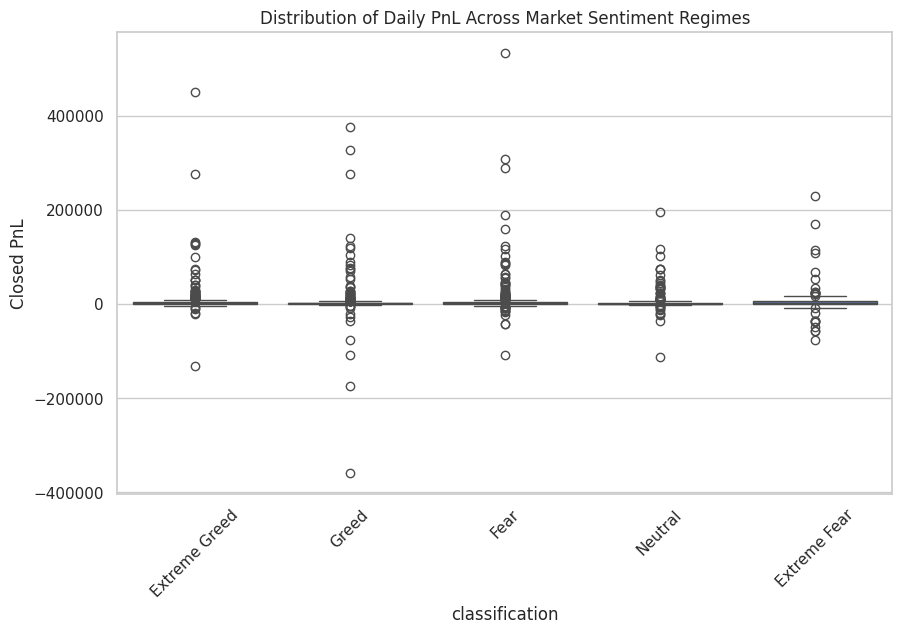

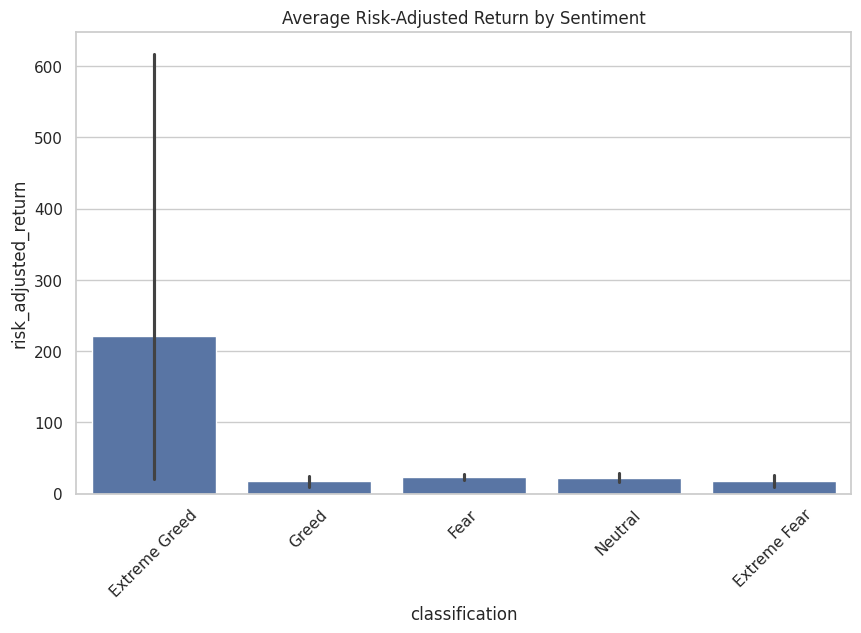

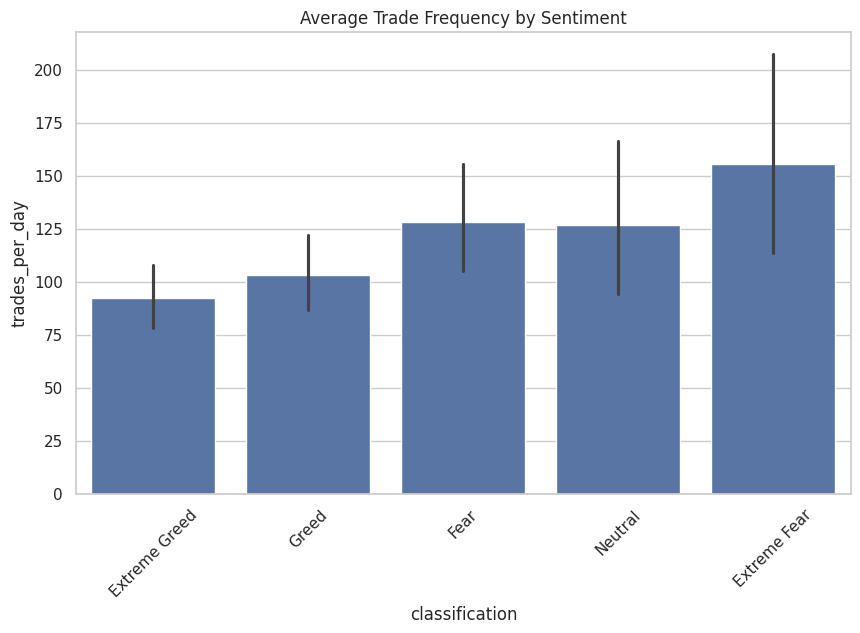

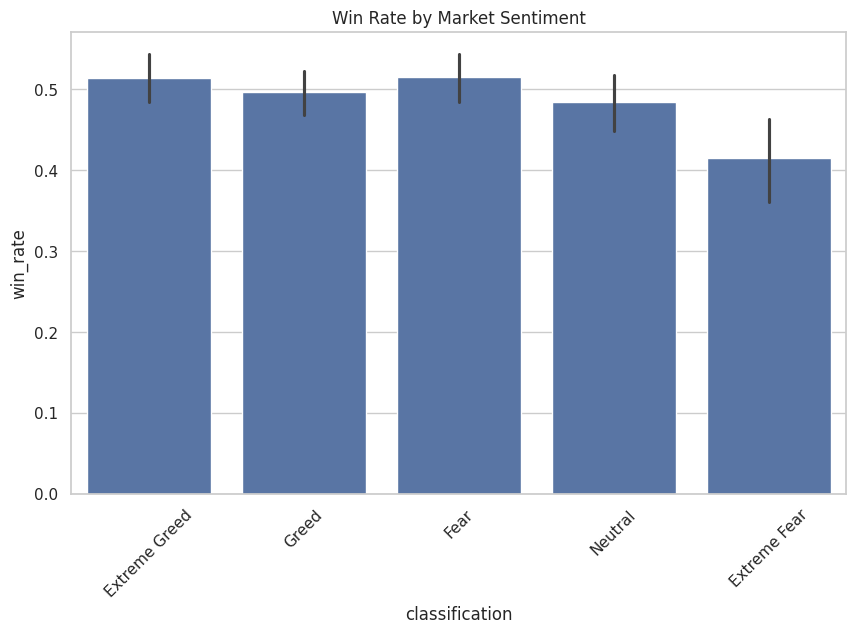

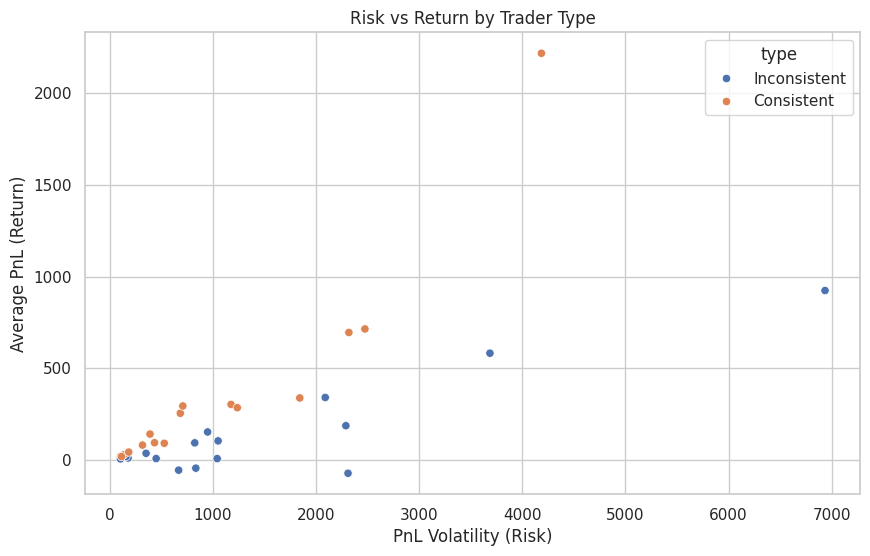

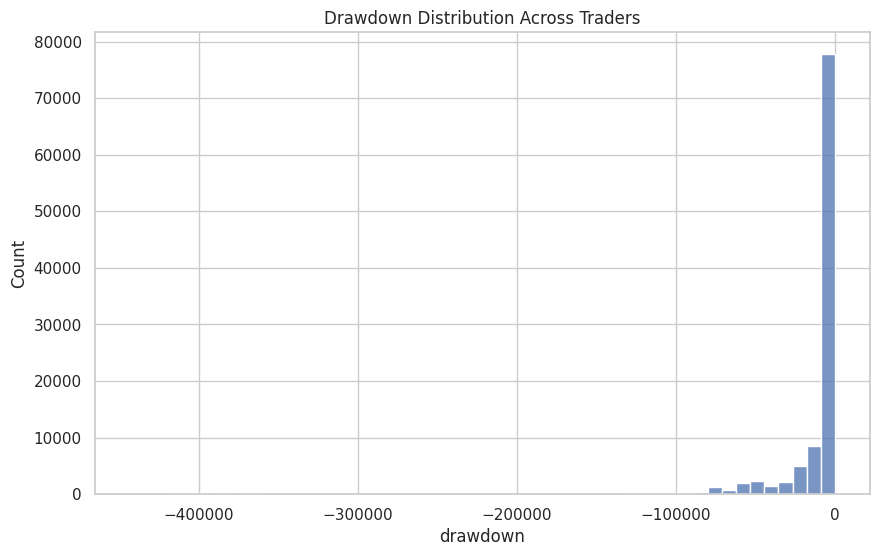

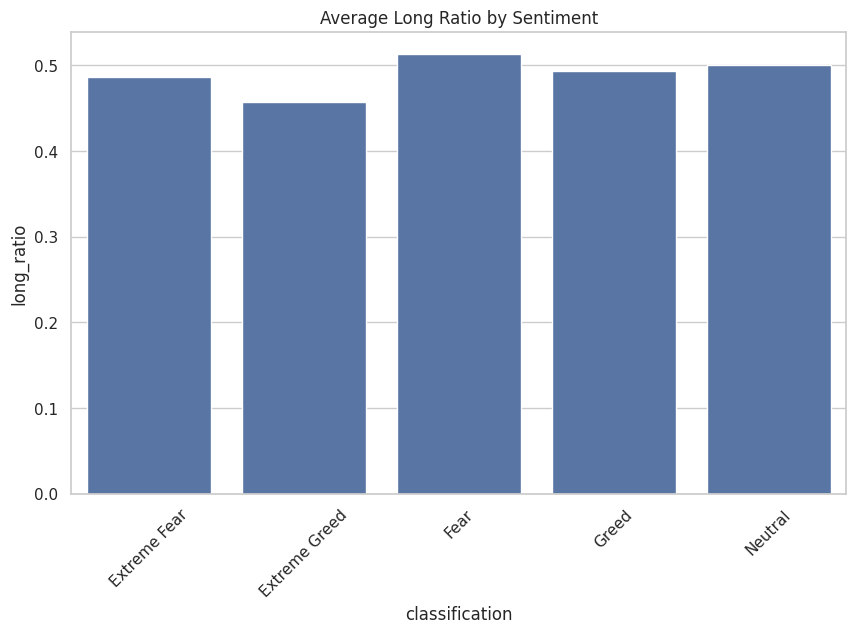

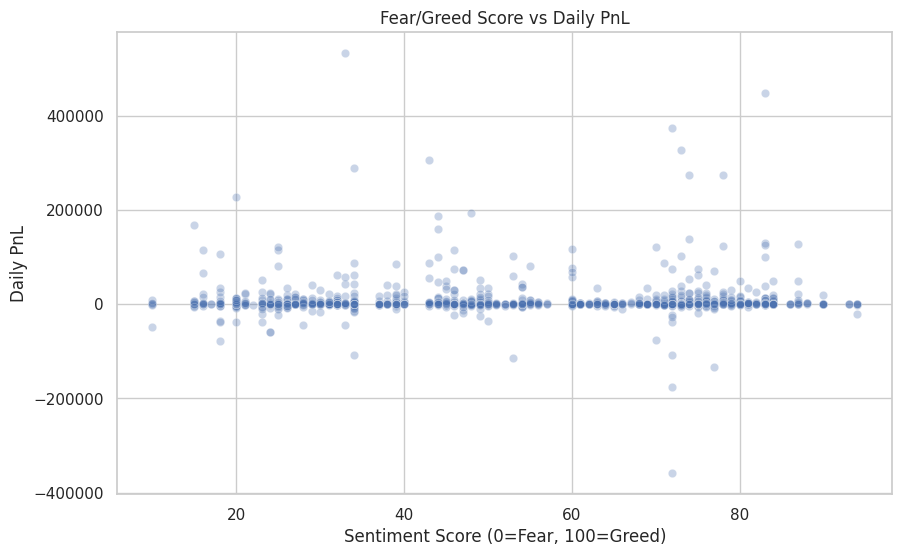

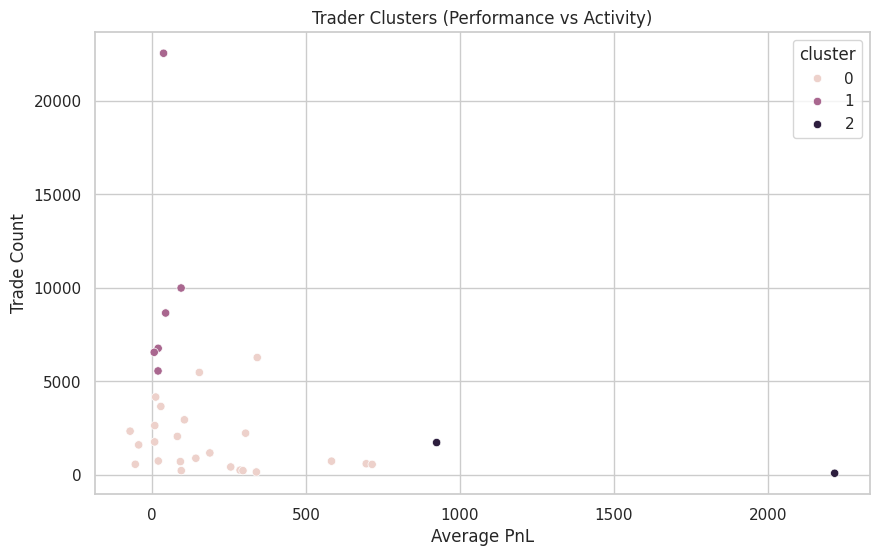

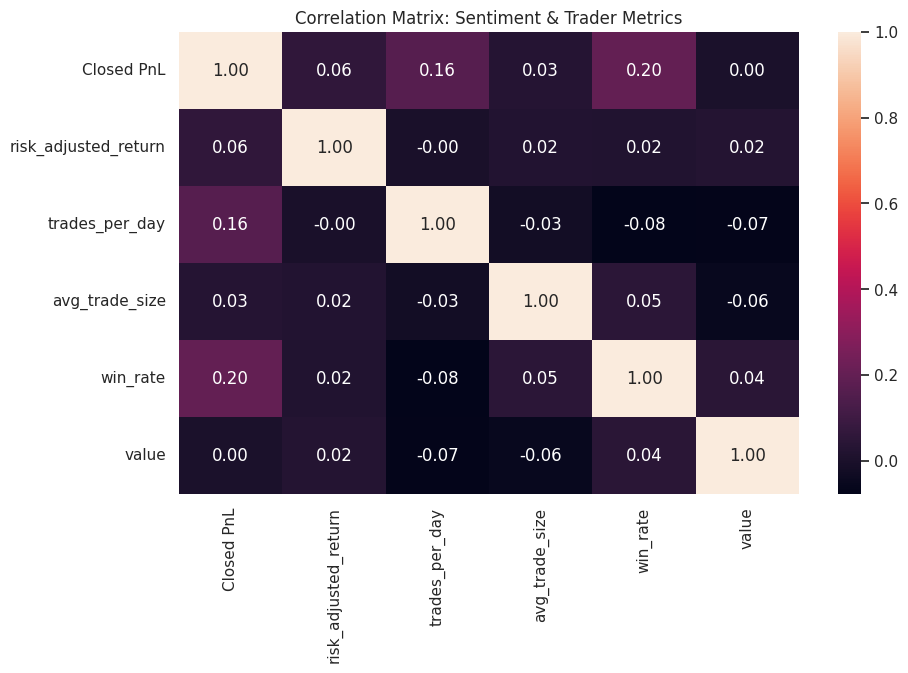

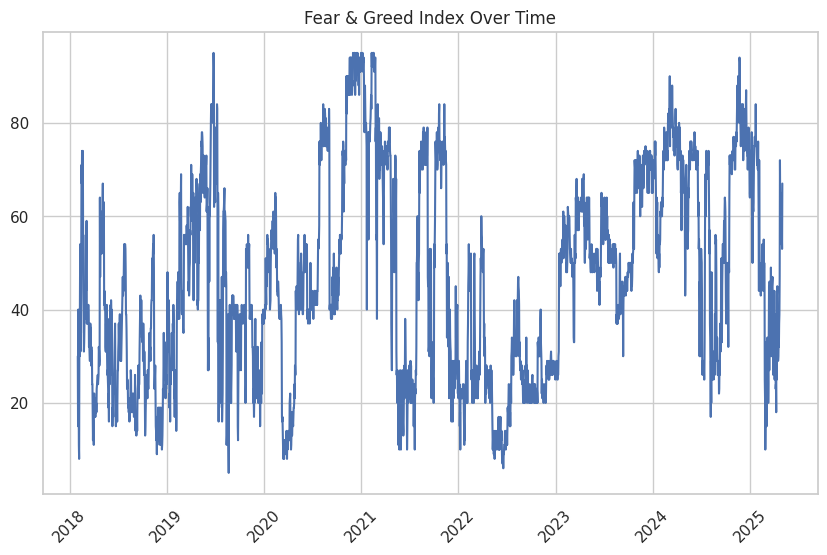

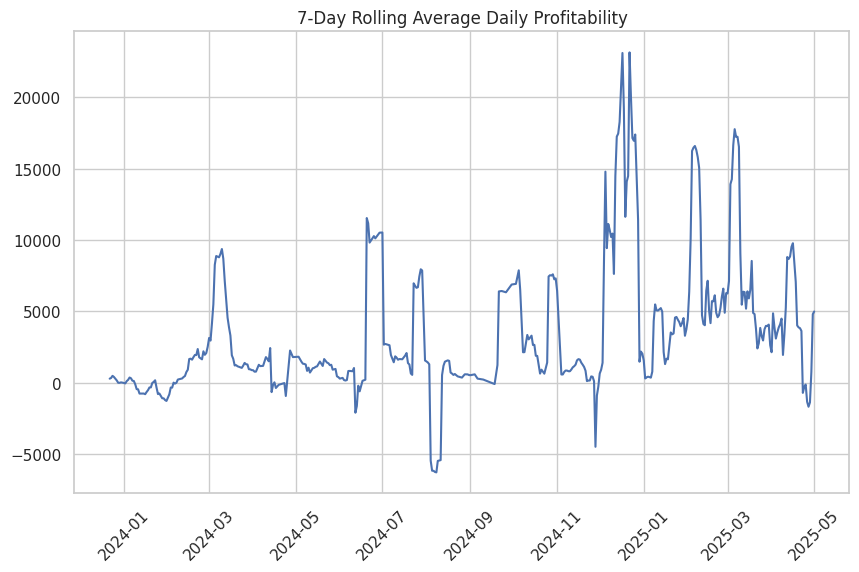

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10,6)
sns.set_theme(style="whitegrid")

# ============================================================
# 1️⃣ PnL Distribution by Sentiment
# ============================================================

plt.figure()
sns.boxplot(data=final_df, x='classification', y='Closed PnL')
plt.xticks(rotation=45)
plt.title("Distribution of Daily PnL Across Market Sentiment Regimes")
plt.show()

# Insight:
# Shows volatility expansion during Fear vs Greed.


# ============================================================
# 2️⃣ Risk-Adjusted Return by Sentiment
# ============================================================

plt.figure()
sns.barplot(data=final_df, x='classification', y='risk_adjusted_return')
plt.xticks(rotation=45)
plt.title("Average Risk-Adjusted Return by Sentiment")
plt.show()

# Insight:
# Identifies which regime produces more efficient returns.


# ============================================================
# 3️⃣ Trade Frequency Shift
# ============================================================

plt.figure()
sns.barplot(data=final_df, x='classification', y='trades_per_day')
plt.xticks(rotation=45)
plt.title("Average Trade Frequency by Sentiment")
plt.show()

# Insight:
# Highlights overtrading during Greed periods.


# ============================================================
# 4️⃣ Win Rate Comparison
# ============================================================

plt.figure()
sns.barplot(data=final_df, x='classification', y='win_rate')
plt.xticks(rotation=45)
plt.title("Win Rate by Market Sentiment")
plt.show()

# Insight:
# Observe psychological impact of Fear on trader accuracy.


# ============================================================
# 5️⃣ Risk vs Return Scatter (Trader-Level)
# ============================================================

plt.figure()
sns.scatterplot(data=trader_stats,
                x='pnl_std',
                y='avg_pnl',
                hue='type')

plt.title("Risk vs Return by Trader Type")
plt.xlabel("PnL Volatility (Risk)")
plt.ylabel("Average PnL (Return)")
plt.show()

# Insight:
# Identifies high-risk gamblers vs stable performers.


# ============================================================
# 6️⃣ Drawdown Distribution
# ============================================================

plt.figure()
sns.histplot(closed_trades['drawdown'], bins=50)
plt.title("Drawdown Distribution Across Traders")
plt.show()

# Insight:
# Fat tails indicate extreme downside risk.


# ============================================================
# 7️⃣ Long/Short Bias by Sentiment
# ============================================================

bias_summary = direction_behavior.groupby('classification')['long_ratio'].mean().reset_index()

plt.figure()
sns.barplot(data=bias_summary, x='classification', y='long_ratio')
plt.xticks(rotation=45)
plt.title("Average Long Ratio by Sentiment")
plt.show()

# Insight:
# Traders reduce long exposure during Fear regimes.


# ============================================================
# 8️⃣ Sentiment Score vs Profitability
# ============================================================

plt.figure()
sns.scatterplot(data=final_df,
                x='value',
                y='Closed PnL',
                alpha=0.3)

plt.title("Fear/Greed Score vs Daily PnL")
plt.xlabel("Sentiment Score (0=Fear, 100=Greed)")
plt.ylabel("Daily PnL")
plt.show()

# Insight:
# Detect nonlinear relationship between sentiment and profitability.


# ============================================================
# 9️⃣ Cluster Visualization
# ============================================================

plt.figure()
sns.scatterplot(data=trader_stats,
                x='avg_pnl',
                y='trade_count',
                hue='cluster')

plt.title("Trader Clusters (Performance vs Activity)")
plt.xlabel("Average PnL")
plt.ylabel("Trade Count")
plt.show()

# Insight:
# Distinguishes high-frequency traders from consistent earners.


# ============================================================
# 🔟 Correlation Heatmap
# ============================================================

corr = final_df[['Closed PnL',
                 'risk_adjusted_return',
                 'trades_per_day',
                 'avg_trade_size',
                 'win_rate',
                 'value']].corr()

plt.figure()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix: Sentiment & Trader Metrics")
plt.show()

# Insight:
# Reveals key drivers of profitability.


# ============================================================
# 1️⃣1️⃣ Sentiment Regime Over Time
# ============================================================

sent_sorted = sent.sort_values('date')

plt.figure()
plt.plot(sent_sorted['date'], sent_sorted['value'])
plt.title("Fear & Greed Index Over Time")
plt.xticks(rotation=45)
plt.show()

# Insight:
# Provides macro context for behavioral shifts.


# ============================================================
# 1️⃣2️⃣ Rolling Profitability Trend
# ============================================================

final_df_sorted = final_df.sort_values('date')
rolling_profit = final_df_sorted.groupby('date')['Closed PnL'].mean().rolling(7).mean()

plt.figure()
plt.plot(rolling_profit.index, rolling_profit.values)
plt.title("7-Day Rolling Average Daily Profitability")
plt.xticks(rotation=45)
plt.show()

# Insight:
# Smooth trend shows profitability cycles aligned with sentiment swings.

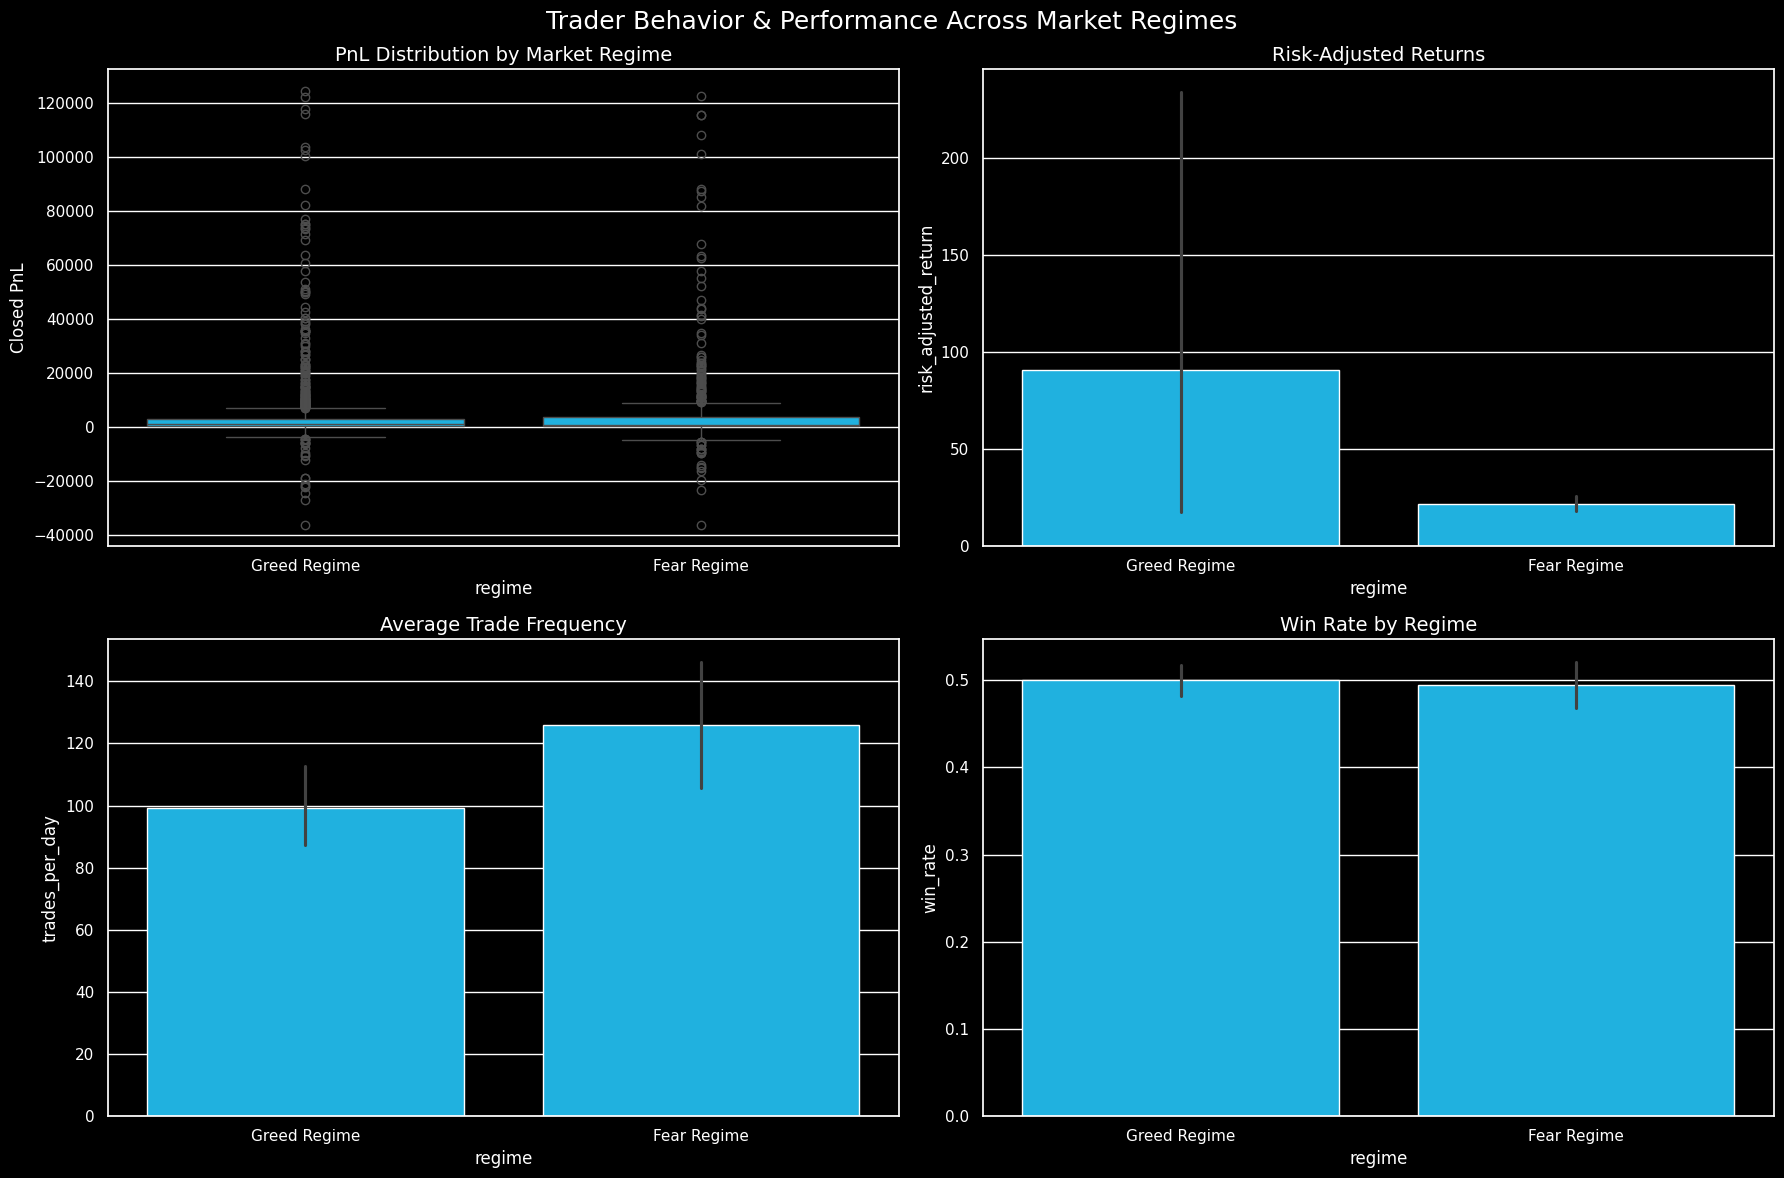

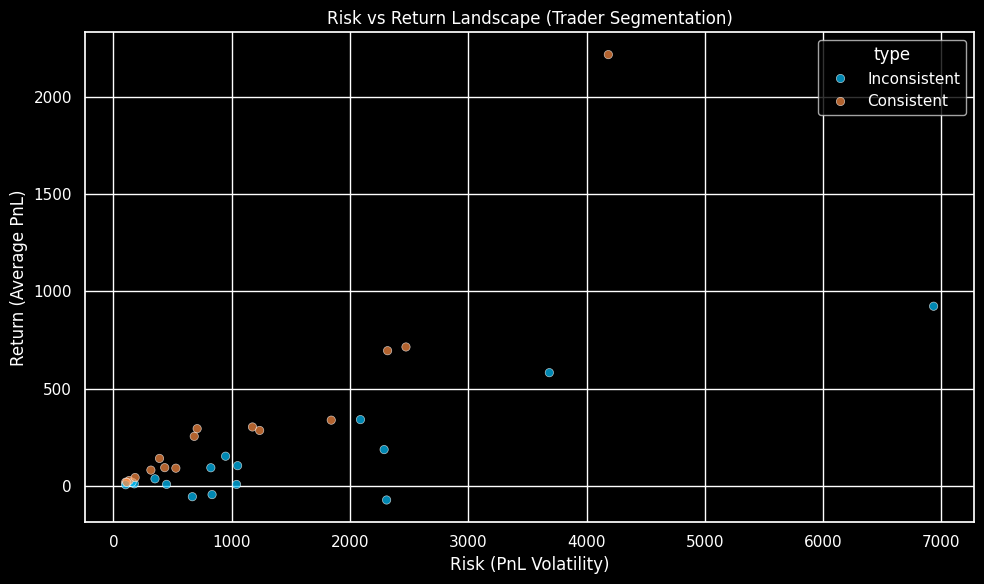

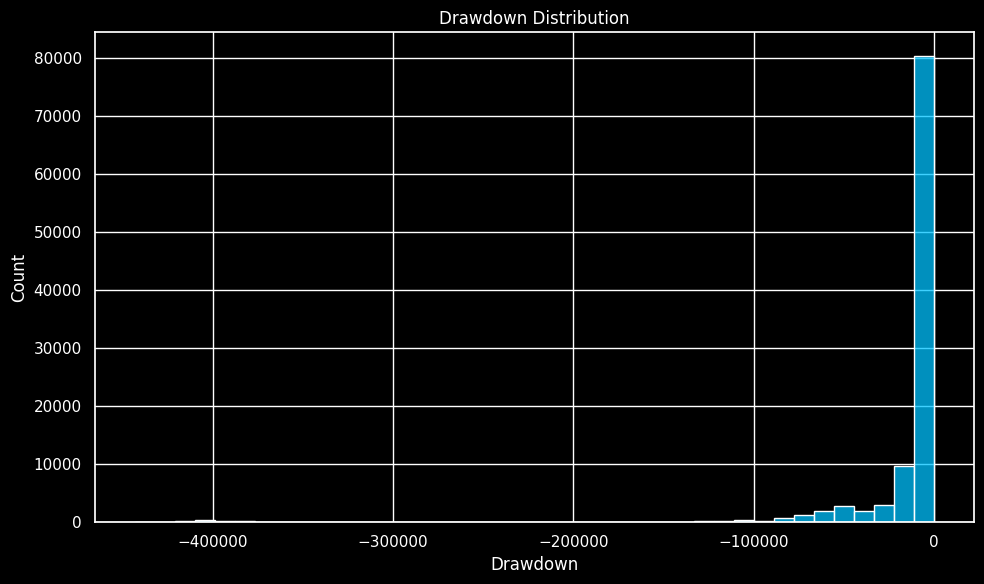

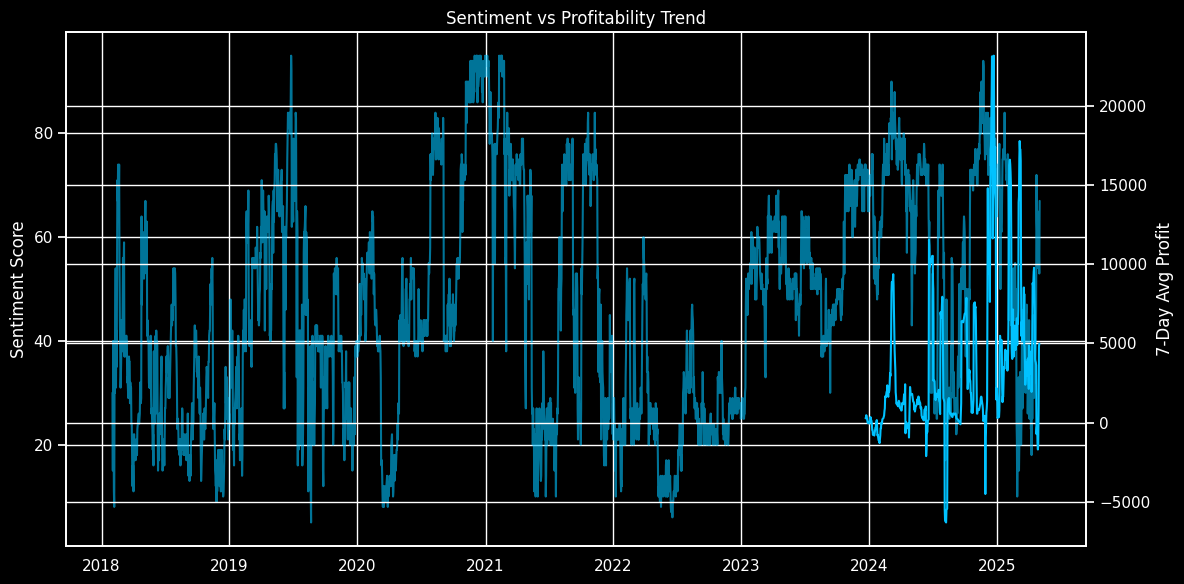

In [4]:
# ============================================================
# CLEAN & PREMIUM VISUALIZATION LAYER
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# 1️⃣ CREATE SIMPLIFIED REGIME
# -----------------------------

final_df['regime'] = np.where(
    final_df['classification'].str.contains("Fear", na=False),
    "Fear Regime",
    "Greed Regime"
)

# -----------------------------
# 2️⃣ REMOVE EXTREME OUTLIERS (1%–99%)
# -----------------------------

lower = final_df['Closed PnL'].quantile(0.01)
upper = final_df['Closed PnL'].quantile(0.99)

clean_df = final_df[
    (final_df['Closed PnL'] >= lower) &
    (final_df['Closed PnL'] <= upper)
]

# -----------------------------
# 3️⃣ DARK THEME SETTINGS
# -----------------------------

plt.style.use("dark_background")
sns.set_palette(["#00C2FF", "#FF8C42"])  # Fear vs Greed palette

# ============================================================
# 📊 MAIN DASHBOARD
# ============================================================

fig = plt.figure(figsize=(18,12))

# ------------------------------------------------------------
# PANEL 1 — PnL Distribution
# ------------------------------------------------------------

ax1 = plt.subplot(2,2,1)
sns.boxplot(data=clean_df, x='regime', y='Closed PnL')
ax1.set_title("PnL Distribution by Market Regime", fontsize=14)

# ------------------------------------------------------------
# PANEL 2 — Risk-Adjusted Returns
# ------------------------------------------------------------

ax2 = plt.subplot(2,2,2)
sns.barplot(data=clean_df, x='regime', y='risk_adjusted_return')
ax2.set_title("Risk-Adjusted Returns", fontsize=14)

# ------------------------------------------------------------
# PANEL 3 — Trade Frequency
# ------------------------------------------------------------

ax3 = plt.subplot(2,2,3)
sns.barplot(data=clean_df, x='regime', y='trades_per_day')
ax3.set_title("Average Trade Frequency", fontsize=14)

# ------------------------------------------------------------
# PANEL 4 — Win Rate
# ------------------------------------------------------------

ax4 = plt.subplot(2,2,4)
sns.barplot(data=clean_df, x='regime', y='win_rate')
ax4.set_title("Win Rate by Regime", fontsize=14)

plt.suptitle("Trader Behavior & Performance Across Market Regimes",
             fontsize=18)

plt.tight_layout()
plt.show()


# ============================================================
# 📉 RISK vs RETURN MAP
# ============================================================

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=trader_stats,
    x='pnl_std',
    y='avg_pnl',
    hue='type',
    alpha=0.7
)

plt.title("Risk vs Return Landscape (Trader Segmentation)")
plt.xlabel("Risk (PnL Volatility)")
plt.ylabel("Return (Average PnL)")
plt.tight_layout()
plt.show()


# ============================================================
# 📉 DRAWDOWN PROFILE
# ============================================================

plt.figure(figsize=(10,6))
sns.histplot(closed_trades['drawdown'], bins=40)
plt.title("Drawdown Distribution")
plt.xlabel("Drawdown")
plt.tight_layout()
plt.show()


# ============================================================
# 📈 SENTIMENT TREND + PROFIT TREND
# ============================================================

fig, ax1 = plt.subplots(figsize=(12,6))

sent_sorted = sent.sort_values('date')
rolling_profit = final_df.sort_values('date') \
                         .groupby('date')['Closed PnL'] \
                         .mean() \
                         .rolling(7).mean()

ax1.plot(sent_sorted['date'], sent_sorted['value'], alpha=0.6)
ax1.set_ylabel("Sentiment Score")

ax2 = ax1.twinx()
ax2.plot(rolling_profit.index, rolling_profit.values)
ax2.set_ylabel("7-Day Avg Profit")

plt.title("Sentiment vs Profitability Trend")
plt.tight_layout()
plt.show()